In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import pickle


In [2]:
data = pd.read_csv('taxi_fare_data.csv')

In [3]:
data

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,day,dayOfWeek,hour,day_name,time_of_day
0,4.50,-73.844311,40.721319,-73.841610,40.712278,1.0,1,15,2,17,Tuesday,Evening
1,16.90,-74.016048,40.711303,-73.979268,40.782004,1.0,2,5,3,16,Wednesday,Evening
2,5.70,-73.982738,40.761270,-73.991242,40.750562,2.0,3,18,5,0,Friday,Night
3,7.70,-73.987130,40.733143,NaN,40.758092,1.0,4,21,7,4,Sunday,Morning
4,5.30,-73.968095,40.768008,-73.956655,40.783762,1.0,2,9,3,7,Wednesday,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,8.10,-73.996214,40.726749,-74.009943,40.709942,1.0,3,7,5,9,Friday,Midday
1048571,9.70,-73.983244,40.730378,NaN,40.766790,2.0,2,24,1,19,Monday,Night
1048572,6.90,-73.983217,40.767932,-73.984292,40.754990,1.0,3,23,2,12,Tuesday,Midday
1048573,30.27,-73.997512,40.683585,-73.955395,40.582122,5.0,5,25,1,11,Monday,Midday


In [6]:
# data cleaning

data.isnull().sum()


fare_amount              0
pickup_longitude     66866
pickup_latitude      66933
dropoff_longitude    66954
dropoff_latitude     66943
passenger_count      66934
year                     0
day                      0
dayOfWeek                0
hour                     0
day_name                 0
time_of_day          66902
dtype: int64

In [8]:
# Fill numerical columns with median
num_cols = [
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'passenger_count'
]

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

# Fill categorical column with mode
data['time_of_day'].fillna(data['time_of_day'].mode()[0], inplace=True)


In [9]:
data.isnull().sum()

fare_amount          0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
year                 0
day                  0
dayOfWeek            0
hour                 0
day_name             0
time_of_day          0
dtype: int64

In [11]:
# data pre processing 

# encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['day_name'] = le.fit_transform(data['day_name'])
data['time_of_day'] = le.fit_transform(data['time_of_day'])


In [12]:
data

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,day,dayOfWeek,hour,day_name,time_of_day
0,4.50,-73.844311,40.721319,-73.841610,40.712278,1.0,1,15,2,17,5,0
1,16.90,-74.016048,40.711303,-73.979268,40.782004,1.0,2,5,3,16,6,0
2,5.70,-73.982738,40.761270,-73.991242,40.750562,2.0,3,18,5,0,0,3
3,7.70,-73.987130,40.733143,-73.980592,40.758092,1.0,4,21,7,4,3,2
4,5.30,-73.968095,40.768008,-73.956655,40.783762,1.0,2,9,3,7,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,8.10,-73.996214,40.726749,-74.009943,40.709942,1.0,3,7,5,9,0,1
1048571,9.70,-73.983244,40.730378,-73.980592,40.766790,2.0,2,24,1,19,1,3
1048572,6.90,-73.983217,40.767932,-73.984292,40.754990,1.0,3,23,2,12,5,1
1048573,30.27,-73.997512,40.683585,-73.955395,40.582122,5.0,5,25,1,11,1,1


In [14]:
#checking the data have correct data dtype
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   fare_amount        1048575 non-null  float64
 1   pickup_longitude   1048575 non-null  float64
 2   pickup_latitude    1048575 non-null  float64
 3   dropoff_longitude  1048575 non-null  float64
 4   dropoff_latitude   1048575 non-null  float64
 5   passenger_count    1048575 non-null  float64
 6   year               1048575 non-null  int64  
 7   day                1048575 non-null  int64  
 8   dayOfWeek          1048575 non-null  int64  
 9   hour               1048575 non-null  int64  
 10  day_name           1048575 non-null  int32  
 11  time_of_day        1048575 non-null  int32  
dtypes: float64(6), int32(2), int64(4)
memory usage: 88.0 MB


In [15]:
#remove impossible value

data = data[
    (data['pickup_longitude'] > -180) & (data['pickup_longitude'] < 180) &
    (data['dropoff_longitude'] > -180) & (data['dropoff_longitude'] < 180) &
    (data['pickup_latitude'] > -90) & (data['pickup_latitude'] < 90) &
    (data['dropoff_latitude'] > -90) & (data['dropoff_latitude'] < 90)
]


In [16]:
#remoove extreem outlier

data = data[data['fare_amount'] > 0]
data = data[data['fare_amount'] < 200]
data = data[data['passenger_count'] <= 6]


In [17]:
#feature engeneering


def calculate_distance(lat1, lon1, lat2, lon2):
    return np.sqrt((lat2 - lat1)**2 + (lon2 - lon1)**2)

data['distance'] = calculate_distance(
    data['pickup_latitude'],
    data['pickup_longitude'],
    data['dropoff_latitude'],
    data['dropoff_longitude']
)





In [20]:
X = data.drop('fare_amount', axis=1)
y = data['fare_amount']


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#modeling

In [22]:
#split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
#linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [24]:
# decision tree traing
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,        # prevents overfitting
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)

In [25]:
# make prediction
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)


In [31]:
# model evaluation 

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# Linear Regression metrics
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

# Decision Tree metrics
dt_r2 = r2_score(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae = mean_absolute_error(y_test, dt_pred)



In [32]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R2 Score": [lr_r2, dt_r2],
    "RMSE": [lr_rmse, dt_rmse],
    "MAE": [lr_mae, dt_mae]
})

results


,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.487091,4.876503,3.086830
1,Decision Tree,0.771695,3.253462,2.006543


In [33]:
best_model = results.loc[results['RMSE'].idxmin()]

print("Best Model is:")
print(best_model)


Best Model is:
Model       Decision Tree
R2 Score         0.771695
RMSE             3.253462
MAE              2.006543
Name: 1, dtype: object


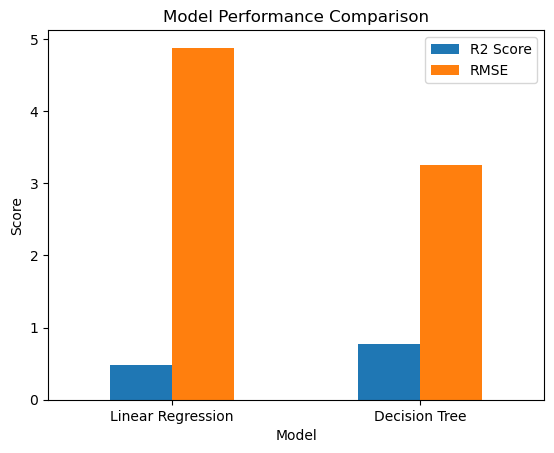

In [34]:
import matplotlib.pyplot as plt

results.set_index("Model")[["R2 Score", "RMSE"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


In [35]:
# save the best model

import pickle

if lr_rmse < dt_rmse:
    pickle.dump(lr, open("model.pkl", "wb"))
    print("Linear Regression saved")
else:
    pickle.dump(dt, open("model.pkl", "wb"))
    print("Decision Tree saved")


Decision Tree saved


In [ ]:
# streamlit run app.py
